=== Challenge A ===
Linear MSE: 0.06875116268831874 R2: 0.9346647371126836
Cubic  MSE: 0.06685568988377963 R2: 0.9364660333982716
Better fit: Cubic


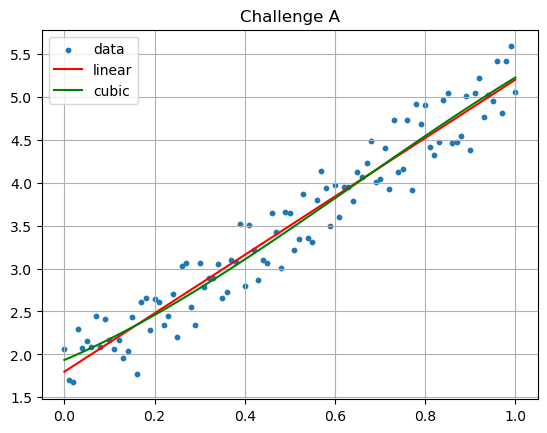


=== Challenge B ===
degree | MSE | R2
3 0.06685568988377963 0.9364660333982716
4 0.06673674757552751 0.9365790660609089
5 0.0664457609054604 0.9368555950655416
6 0.06621452191974167 0.9370753449480305
7 0.0659900938301953 0.9372886223335531
8 0.06524132612597397 0.9380001875330919
9 0.06523690709679633 0.9380043870029152
10 0.0649116808984579 0.9383134543457122
11 0.06416518555585413 0.9390228600858636
12 0.06405760245087963 0.9391250979269545
13 0.0629506095454533 0.9401770899175236
14 0.06224767899049685 0.9408450953854138
15 0.061702202712574365 0.9413634696880918
16 0.06159084147694452 0.9414692979435109
17 0.061140128176934226 0.9418976175644673
18 0.06047030996462614 0.9425341558756266
19 0.06027155471024914 0.9427230359801542
20 0.05980953039680005 0.9431621046271293
21 0.05981978264064907 0.9431523617657599
22 0.0598311810558813 0.9431415296805038
23 0.0598229297777725 0.9431493709940658
24 0.05982925115385243 0.9431433636953985
25 0.05983495073420934 0.9431379472985493
26 0.0

/tmp/ipykernel_906/3943505308.py:49: RankWarning: Polyfit may be poorly conditioned
  y_pred = np.poly1d(np.polyfit(X, Y, deg))(X)
/tmp/ipykernel_906/3943505308.py:49: RankWarning: Polyfit may be poorly conditioned
  y_pred = np.poly1d(np.polyfit(X, Y, deg))(X)
/tmp/ipykernel_906/3943505308.py:49: RankWarning: Polyfit may be poorly conditioned
  y_pred = np.poly1d(np.polyfit(X, Y, deg))(X)
/tmp/ipykernel_906/3943505308.py:49: RankWarning: Polyfit may be poorly conditioned
  y_pred = np.poly1d(np.polyfit(X, Y, deg))(X)
/tmp/ipykernel_906/3943505308.py:49: RankWarning: Polyfit may be poorly conditioned
  y_pred = np.poly1d(np.polyfit(X, Y, deg))(X)
/tmp/ipykernel_906/3943505308.py:49: RankWarning: Polyfit may be poorly conditioned
  y_pred = np.poly1d(np.polyfit(X, Y, deg))(X)
/tmp/ipykernel_906/3943505308.py:49: RankWarning: Polyfit may be poorly conditioned
  y_pred = np.poly1d(np.polyfit(X, Y, deg))(X)
/tmp/ipykernel_906/3943505308.py:49: RankWarning: Polyfit may be poorly conditioned

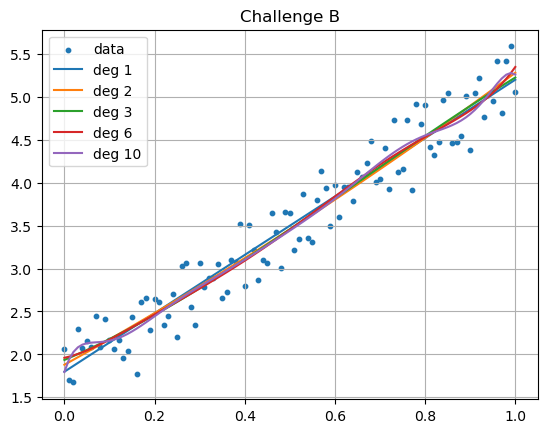


=== Challenge C ===
Vandermonde MSE: 0.06685568988377963 R2: 0.9364660333982715
Coefficients: [-1.14822183  2.21391235  2.22452016  1.93507486]


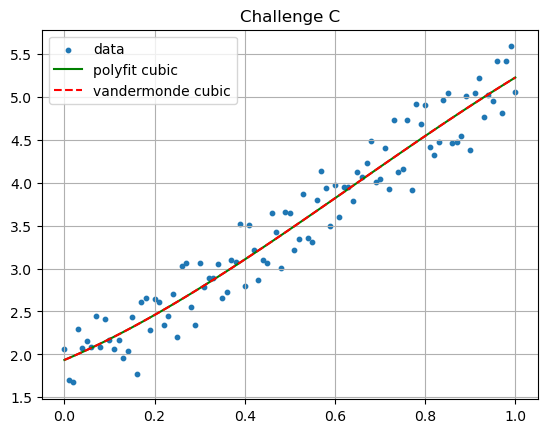

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Data
m_true, b_true = 3.5, 1.2
X = np.sort(np.arange(0, 1.01, 0.01))
Y = m_true * X + b_true + np.random.uniform(0, 1, size=len(X))

A = np.vstack([X, np.ones(len(X))]).T
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
Y_ls = m * X + c

# Challenge A
degree = 3
coefficients = np.polyfit(X, Y, degree)
polynomial = np.poly1d(coefficients)
Y_poly = polynomial(X)

# MSE
mse_ls   = np.mean((Y - Y_ls)   ** 2)
mse_poly = np.mean((Y - Y_poly) ** 2)

# R-squared
ss_total = np.sum((Y - np.mean(Y)) ** 2)
r2_ls    = 1 - np.sum((Y - Y_ls)   ** 2) / ss_total
r2_poly  = 1 - np.sum((Y - Y_poly) ** 2) / ss_total

print("=== Challenge A ===")
print("Linear MSE:", mse_ls,   "R2:", r2_ls)
print("Cubic  MSE:", mse_poly, "R2:", r2_poly)
print("Better fit:", "Cubic" if r2_poly > r2_ls else "Linear")

plt.figure()
plt.scatter(X, Y, s=10, label='data')
plt.plot(X, Y_ls,   'r', label='linear')
plt.plot(X, Y_poly, 'g', label='cubic')
plt.legend()
plt.grid()
plt.title('Challenge A')
plt.show()

# Challenge B
print("\n=== Challenge B ===")
print("degree | MSE | R2")

r2_base = 1 - np.sum((Y - Y_poly) ** 2) / ss_total

for deg in range(3, 50):
    y_pred = np.poly1d(np.polyfit(X, Y, deg))(X)
    mse = np.mean((Y - y_pred) ** 2)
    r2  = 1 - np.sum((Y - y_pred) ** 2) / ss_total
    print(deg, mse, r2)
    if r2 > r2_base + 0.01:
        print("overfit at degree", deg)
        break

for deg in range(3, 0, -1):
    y_pred = np.poly1d(np.polyfit(X, Y, deg))(X)
    mse = np.mean((Y - y_pred) ** 2)
    r2  = 1 - np.sum((Y - y_pred) ** 2) / ss_total
    print(deg, mse, r2)
    if r2 < r2_base - 0.001:
        print("underfit at degree", deg)
        break

plt.figure()
plt.scatter(X, Y, s=10, label='data')
for deg in [1, 2, 3, 6, 10]:
    plt.plot(X, np.poly1d(np.polyfit(X, Y, deg))(X), label='deg ' + str(deg))
plt.legend()
plt.grid()
plt.title('Challenge B')
plt.show()

# Challenge C

degree = 3
V = np.vander(X, degree + 1)
coeffs_vander = np.linalg.lstsq(V, Y, rcond=None)[0]
Y_vander = V @ coeffs_vander

mse_vander = np.mean((Y - Y_vander) ** 2)
r2_vander  = 1 - np.sum((Y - Y_vander) ** 2) / ss_total

print("\n=== Challenge C ===")
print("Vandermonde MSE:", mse_vander, "R2:", r2_vander)
print("Coefficients:", coeffs_vander)

plt.figure()
plt.scatter(X, Y, s=10, label='data')
plt.plot(X, Y_poly,   'g', label='polyfit cubic')
plt.plot(X, Y_vander, 'r--', label='vandermonde cubic')
plt.legend()
plt.grid()
plt.title('Challenge C')
plt.show()